# NYC Taxi Fare Predictor
## Client: RideMetrics Inc.
### Phase 1: Setup & Data Ingestion

**Objective:** Load the NYC TLC Yellow Taxi trip data (January 2024) and perform initial inspection to understand the dataset before cleaning.

In [2]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
# Cell 2: Load data
df = pd.read_parquet(r'E:\code\nyc-taxi-fare\data\yellow_tripdata_2024-01.parquet')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 2,964,624 rows × 19 columns


In [4]:
# Cell 3: Initial inspection
print("=== Column Data Types ===")
print(df.dtypes)
print(f"\n=== Null Counts ===")
print(df.isnull().sum())
print(f"\n=== Basic Stats ===")
df.describe()

=== Column Data Types ===
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object

=== Null Counts ===
VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          140162
trip_distance                 0
RatecodeID         

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,2964624.00,2964624,2964624,2824462.00,2964624.00,2824462.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2824462.00,2824462.00
mean,1.75,2024-01-17 00:46:36.431092,2024-01-17 01:02:13.208130,1.34,3.65,2.07,166.02,165.12,1.16,18.18,1.45,0.48,3.34,0.53,0.98,26.80,2.26,0.14
min,1.00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.00,0.00,1.00,1.00,1.00,0.00,-899.00,-7.50,-0.50,-80.00,-80.00,-1.00,-900.00,-2.50,-1.75
25%,2.00,2024-01-09 15:59:19.750000,2024-01-09 16:16:23,1.00,1.00,1.00,132.00,114.00,1.00,8.60,0.00,0.50,1.00,0.00,1.00,15.38,2.50,0.00
50%,2.00,2024-01-17 10:45:37.500000,2024-01-17 11:03:51.500000,1.00,1.68,1.00,162.00,162.00,1.00,12.80,1.00,0.50,2.70,0.00,1.00,20.10,2.50,0.00
75%,2.00,2024-01-24 18:23:52.250000,2024-01-24 18:40:29,1.00,3.11,1.00,234.00,234.00,1.00,20.50,2.50,0.50,4.12,0.00,1.00,28.56,2.50,0.00
max,6.00,2024-02-01 00:01:15,2024-02-02 13:56:52,9.00,312722.30,99.00,265.00,265.00,4.00,5000.00,14.25,4.00,428.00,115.92,1.00,5000.00,2.50,1.75
std,0.43,NaN,NaN,0.85,225.46,9.82,63.62,69.32,0.58,18.95,1.80,0.12,3.90,2.13,0.22,23.39,0.82,0.49


In [5]:
# Cell 4: Preview 10 random rows
df.sample(10, random_state=42)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
1725696,2,2024-01-20 13:31:30,2024-01-20 14:03:25,2.00,17.14,2.00,N,132,233,1,70.00,0.00,0.50,8.27,6.94,1.00,90.96,2.50,1.75
1581136,2,2024-01-18 21:52:46,2024-01-18 22:03:21,1.00,2.49,1.00,N,163,75,1,13.50,1.00,0.50,4.00,0.00,1.00,22.50,2.50,0.00
19137,2,2024-01-01 03:43:58,2024-01-01 03:50:47,2.00,1.84,1.00,N,127,20,2,10.00,1.00,0.50,0.00,0.00,1.00,12.50,0.00,0.00
1682810,1,2024-01-19 22:20:12,2024-01-19 22:50:12,1.00,3.60,1.00,N,186,263,1,23.30,3.50,0.50,5.65,0.00,1.00,33.95,2.50,0.00
511035,2,2024-01-06 22:41:50,2024-01-06 22:43:24,1.00,0.04,1.00,N,238,238,2,3.70,1.00,0.50,0.00,0.00,1.00,6.20,0.00,0.00
847543,1,2024-01-11 08:00:34,2024-01-11 08:07:21,1.00,0.70,1.00,N,161,163,1,7.20,2.50,0.50,2.80,0.00,1.00,14.00,2.50,0.00
1052356,2,2024-01-13 08:10:30,2024-01-13 08:13:05,1.00,0.66,1.00,N,140,141,2,5.10,0.00,0.50,0.00,0.00,1.00,9.10,2.50,0.00
1366596,1,2024-01-16 18:31:29,2024-01-16 18:44:49,1.00,2.70,1.00,N,161,239,1,16.30,5.00,0.50,2.50,0.00,1.00,25.30,2.50,0.00
304475,2,2024-01-04 20:52:19,2024-01-04 21:03:31,1.00,2.00,1.00,N,239,141,1,13.50,1.00,0.50,0.00,0.00,1.00,18.50,2.50,0.00
989548,2,2024-01-12 15:08:58,2024-01-12 15:45:39,1.00,9.33,1.00,N,138,61,1,43.60,5.00,0.50,7.78,0.00,1.00,59.63,0.00,1.75


## Phase 1 Observations

- **Rows:** 2,964,624
- **Columns:** 19
- **Key datetime columns:** tpep_pickup_datetime, tpep_dropoff_datetime
- **Target variable:** fare_amount

### Data Types
- Datetime columns are already parsed as `datetime64` — no conversion needed
- `passenger_count` and `RatecodeID` are `float64` instead of int — indicates hidden nulls
- `store_and_fwd_flag` is a string column — will be dropped as it won't be used in modeling

### Null Counts
- Most columns have zero nulls
- `passenger_count`, `RatecodeID`, `congestion_surcharge`, and `Airport_fee` each have **140,162 null values**

### Potential Issues Spotted (to be fixed in Phase 2)
| Column | Issue | Evidence |
|---|---|---|
| fare_amount | Negative values present | min = -899.00 |
| trip_distance | Zero and extreme values present | min = 0.00, max = 312,722 miles |
| passenger_count | Zero passenger trips present | min = 0.00 |
| tpep_pickup_datetime | Trips dated back to 2002 | min = 2002-12-31 |
| fare_amount | Extreme outliers present | max = $5,000 |

### Summary
The dataset is large and messy with real-world noise. Negative fares, zero-distance trips, impossible distances, and trips from 2002 all need to be removed before modeling. For RideMetrics Inc., a clean dataset is essential to ensure our fare predictions are based on legitimate trip patterns only.

## Phase 2: Data Cleaning

Applying business rules to remove invalid, corrupt, and extreme records before modeling.
Each rule is justified by real-world logic.

In [6]:
# Cell 5: Data Cleaning

# Record starting row count
original_count = len(df)
print(f"Starting rows: {original_count:,}")

# --- Rule 1: Remove fares <= 0 ---
# A trip must have a positive fare to be a legitimate transaction
df = df[df['fare_amount'] > 0]
print(f"After removing fare_amount <= 0:       {len(df):,} rows remaining  ({original_count - len(df):,} removed)")

# --- Rule 2: Remove zero or extreme trip distances ---
# Trips of 0 miles never happened; 100+ miles are almost certainly data errors for NYC
r2 = len(df)
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] <= 100)]
print(f"After removing invalid trip_distance:  {len(df):,} rows remaining  ({r2 - len(df):,} removed)")

# --- Rule 3: Remove nulls in key columns ---
# We cannot model a trip with missing core fields
r3 = len(df)
key_cols = ['fare_amount', 'trip_distance', 'passenger_count',
            'tpep_pickup_datetime', 'tpep_dropoff_datetime']
df = df.dropna(subset=key_cols)
print(f"After removing nulls in key columns:   {len(df):,} rows remaining  ({r3 - len(df):,} removed)")

# --- Rule 4: Remove zero-duration trips ---
# A trip with no elapsed time is physically impossible
r4 = len(df)
df['trip_duration_check'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds()
df = df[df['trip_duration_check'] > 0]
df = df.drop(columns=['trip_duration_check'])
print(f"After removing zero-duration trips:    {len(df):,} rows remaining  ({r4 - len(df):,} removed)")

# --- Rule 5: Remove fare outliers above 99th percentile ---
# Extreme fares skew the model — we keep 99% of the distribution
r5 = len(df)
fare_99 = df['fare_amount'].quantile(0.99)
df = df[df['fare_amount'] <= fare_99]
print(f"After removing fare outliers (>{fare_99:.2f}): {len(df):,} rows remaining  ({r5 - len(df):,} removed)")

# --- Rule 6: Remove zero passenger trips ---
# A trip with 0 passengers is not a real fare
r6 = len(df)
df = df[df['passenger_count'] > 0]
print(f"After removing passenger_count = 0:    {len(df):,} rows remaining  ({r6 - len(df):,} removed)")

# --- Final report ---
final_count = len(df)
removed_total = original_count - final_count
print(f"\n{'='*50}")
print(f"Original dataset:  {original_count:,} rows")
print(f"Clean dataset:     {final_count:,} rows")
print(f"Total removed:     {removed_total:,} rows ({removed_total/original_count*100:.1f}% of dataset)")

Starting rows: 2,964,624
After removing fare_amount <= 0:       2,926,283 rows remaining  (38,341 removed)
After removing invalid trip_distance:  2,869,658 rows remaining  (56,625 removed)
After removing nulls in key columns:   2,754,430 rows remaining  (115,228 removed)
After removing zero-duration trips:    2,754,372 rows remaining  (58 removed)
After removing fare outliers (>73.00): 2,727,179 rows remaining  (27,193 removed)
After removing passenger_count = 0:    2,696,781 rows remaining  (30,398 removed)

Original dataset:  2,964,624 rows
Clean dataset:     2,696,781 rows
Total removed:     267,843 rows (9.0% of dataset)


## Phase 2 Cleaning Summary

| Rule | Justification |
|---|---|
| fare_amount > 0 | Negative or zero fares are not real transactions |
| 0 < trip_distance ≤ 100 | Zero-mile trips never happened; 100+ miles unrealistic for NYC |
| No nulls in key columns | Cannot model incomplete records |
| trip_duration > 0 | Zero-duration trips are physically impossible |
| fare_amount ≤ 99th percentile | Extreme outliers distort model training |
| passenger_count > 0 | A trip with no passengers has no legitimate fare |

**Cleaning Results**
- Rows before cleaning: 2,964,624
- Rows after cleaning: 2,696,781
- Rows removed: 267,843 (9.0% of dataset)

**Largest removals:**
- Nulls in key columns: 115,228 rows (primarily passenger_count and RatecodeID)
- Invalid trip distance: 56,625 rows
- Fare outliers above $73.00: 27,193 rows
- Zero passenger trips: 30,398 rows

## Phase 3: Feature Engineering

Extracting meaningful predictive features from raw datetime and trip fields.
These features will serve as inputs to our regression model.

In [7]:
# Cell 6: Feature Engineering

# --- Feature 1: Trip duration in minutes ---
# How long the trip took — strong predictor of fare
df['trip_duration_mins'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# --- Feature 2: Hour of day (0-23) ---
# Rush hour trips tend to cost more due to traffic and time
df['hour_of_day'] = df['tpep_pickup_datetime'].dt.hour

# --- Feature 3: Day of week (0=Monday, 6=Sunday) ---
# Weekend vs weekday patterns differ significantly
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek

# --- Feature 4: Is weekend flag ---
# Binary flag — weekends have different demand patterns
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# --- Feature 5: Speed in mph ---
# Derived from distance and duration — helps detect anomalous trips
df['speed_mph'] = df['trip_distance'] / (df['trip_duration_mins'] / 60)

# --- Rule: Remove physically impossible speeds ---
# NYC taxis cannot sustain 80+ mph — these are data errors
r_before = len(df)
df = df[df['speed_mph'] <= 80]
print(f"Rows removed for speed_mph > 80: {r_before - len(df):,}")

# --- Confirmation ---
print(f"\nFinal dataset after feature engineering: {len(df):,} rows")
print(f"\nNew features added:")
print(df[['trip_duration_mins', 'hour_of_day', 'day_of_week', 
          'is_weekend', 'speed_mph']].describe())

Rows removed for speed_mph > 80: 584

Final dataset after feature engineering: 2,696,197 rows

New features added:
       trip_duration_mins  hour_of_day  day_of_week  is_weekend  speed_mph
count          2696197.00   2696197.00   2696197.00  2696197.00 2696197.00
mean                15.48        14.27         2.87        0.25      11.31
std                 35.63         5.63         1.93        0.44       6.43
min                  0.02         0.00         0.00        0.00       0.00
25%                  7.18        11.00         1.00        0.00       7.34
50%                 11.53        15.00         3.00        0.00       9.59
75%                 18.40        19.00         5.00        1.00      12.93
max               9455.40        23.00         6.00        1.00      80.00


## Phase 3 Feature Summary

| Feature | Source | Why It Matters |
|---|---|---|
| trip_duration_mins | dropoff - pickup time | Longer trips = higher fares |
| hour_of_day | pickup datetime | Rush hour drives up fares |
| day_of_week | pickup datetime | Weekday vs weekend demand differs |
| is_weekend | day_of_week >= 5 | Binary signal for weekend patterns |
| speed_mph | distance / duration | Proxy for traffic conditions |

**Results**
- Rows removed for speed > 80 mph: 584
- Final clean dataset: 2,696,197 rows

**Key observations:**
- Average trip duration: 15.5 minutes — consistent with typical NYC short trips
- Average speed: 11.3 mph — reflect

## Phase 4: Exploratory Data Analysis (EDA)

Five visualizations to understand fare patterns, trip behavior, and demand timing
for RideMetrics Inc. before building the predictive model.

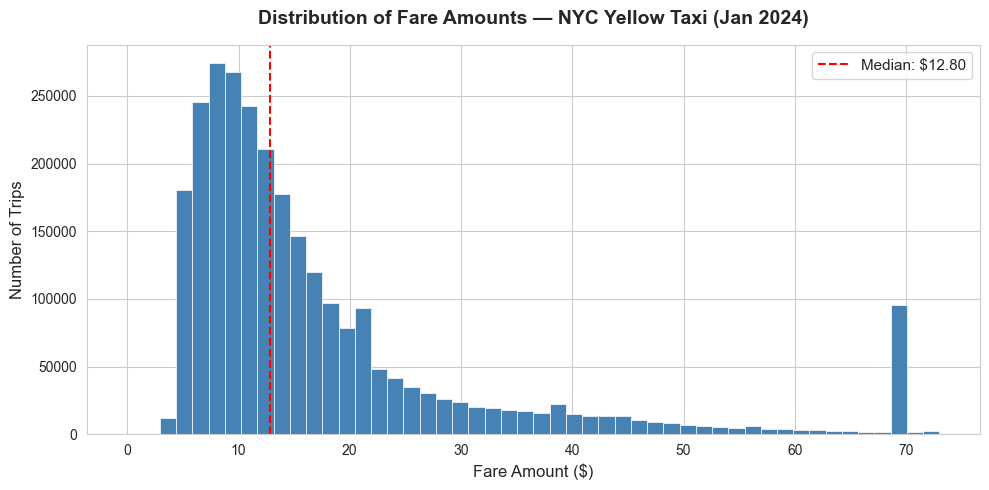

Median fare: $12.80
Mean fare:   $17.61


In [8]:
# Cell 7: Chart 1 — Fare Amount Distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['fare_amount'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_title('Distribution of Fare Amounts — NYC Yellow Taxi (Jan 2024)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Fare Amount ($)', fontsize=12)
ax.set_ylabel('Number of Trips', fontsize=12)

# Add median line
median_fare = df['fare_amount'].median()
ax.axvline(median_fare, color='red', linestyle='--', linewidth=1.5, 
           label=f'Median: ${median_fare:.2f}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"Median fare: ${median_fare:.2f}")
print(f"Mean fare:   ${df['fare_amount'].mean():.2f}")

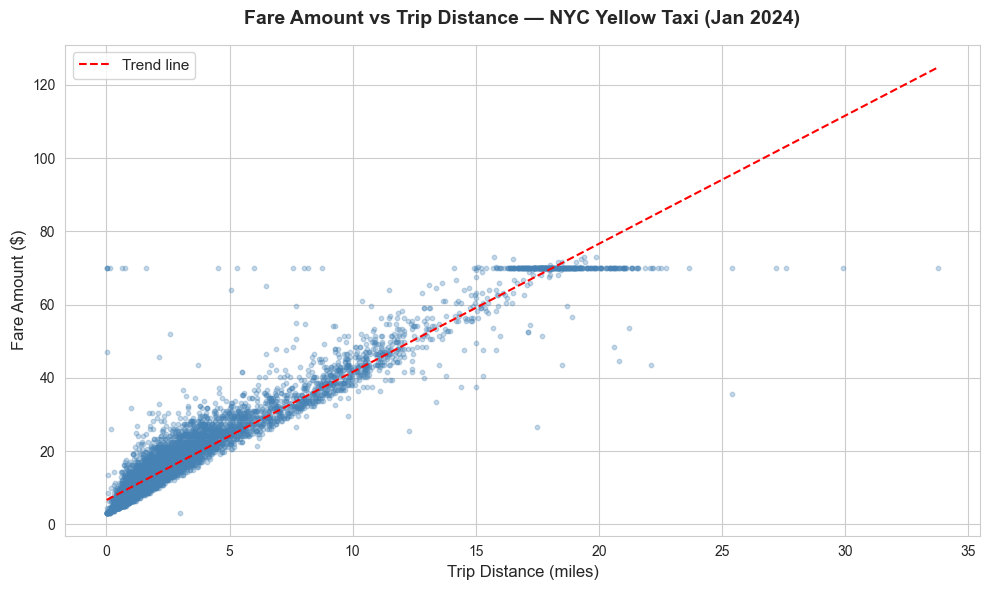

Correlation between trip_distance and fare_amount: 0.959


In [9]:
# Cell 8: Chart 2 — Fare vs Trip Distance (sampled 10k rows)
# We sample 10,000 rows so the scatter plot renders cleanly without overplotting

sample = df.sample(10000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(sample['trip_distance'], sample['fare_amount'], 
           alpha=0.3, color='steelblue', s=10)

ax.set_title('Fare Amount vs Trip Distance — NYC Yellow Taxi (Jan 2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Trip Distance (miles)', fontsize=12)
ax.set_ylabel('Fare Amount ($)', fontsize=12)

# Add a trend reference line
z = np.polyfit(sample['trip_distance'], sample['fare_amount'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['trip_distance'].min(), sample['trip_distance'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=1.5, linestyle='--', label='Trend line')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Correlation coefficient
corr = df['trip_distance'].corr(df['fare_amount'])
print(f"Correlation between trip_distance and fare_amount: {corr:.3f}")

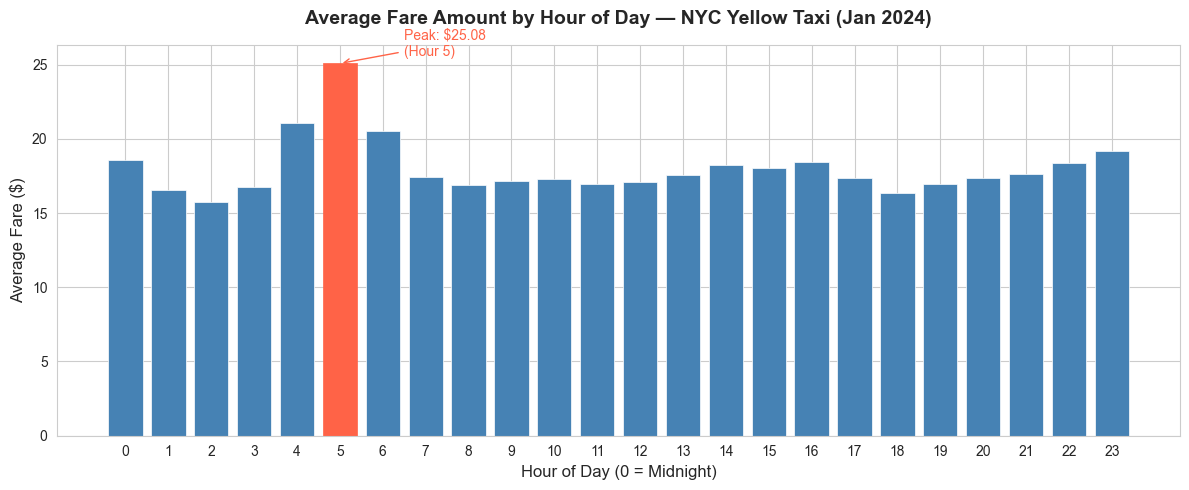

 hour_of_day  fare_amount
           0        18.57
           1        16.55
           2        15.74
           3        16.76
           4        21.04
           5        25.08
           6        20.50
           7        17.46
           8        16.92
           9        17.15
          10        17.31
          11        16.96
          12        17.12
          13        17.55
          14        18.24
          15        18.05
          16        18.47
          17        17.35
          18        16.36
          19        16.98
          20        17.34
          21        17.64
          22        18.37
          23        19.21


In [10]:
# Cell 9: Chart 3 — Average Fare by Hour of Day
hourly_fare = df.groupby('hour_of_day')['fare_amount'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(hourly_fare['hour_of_day'], hourly_fare['fare_amount'],
              color='steelblue', edgecolor='white', linewidth=0.5)

# Highlight the peak hour
peak_hour = hourly_fare.loc[hourly_fare['fare_amount'].idxmax(), 'hour_of_day']
peak_fare = hourly_fare['fare_amount'].max()
bars[peak_hour].set_color('tomato')

ax.set_title('Average Fare Amount by Hour of Day — NYC Yellow Taxi (Jan 2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day (0 = Midnight)', fontsize=12)
ax.set_ylabel('Average Fare ($)', fontsize=12)
ax.set_xticks(range(24))

# Annotate peak
ax.annotate(f'Peak: ${peak_fare:.2f}\n(Hour {peak_hour})',
            xy=(peak_hour, peak_fare),
            xytext=(peak_hour + 1.5, peak_fare + 0.5),
            fontsize=10, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato'))

plt.tight_layout()
plt.show()

print(hourly_fare.to_string(index=False))

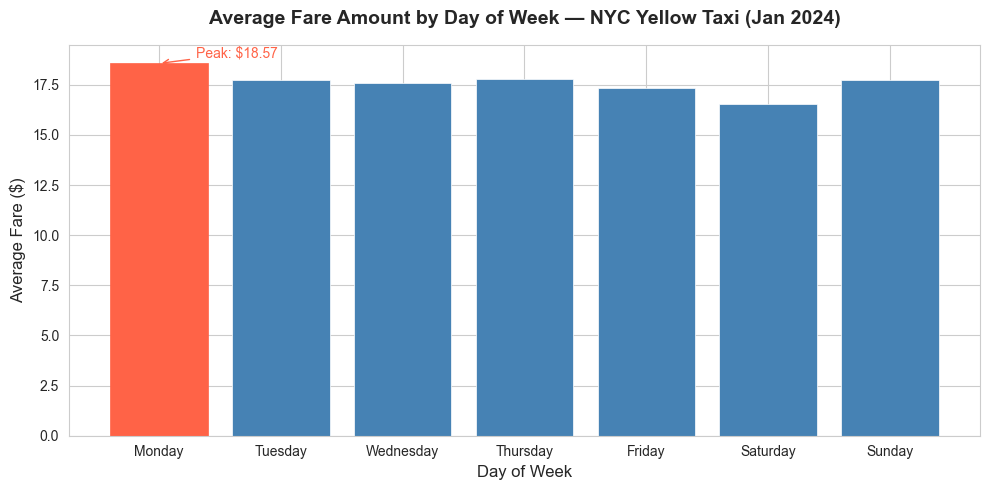

 day_name  fare_amount
   Monday        18.57
  Tuesday        17.72
Wednesday        17.60
 Thursday        17.78
   Friday        17.35
 Saturday        16.54
   Sunday        17.76


In [11]:
# Cell 10: Chart 4 — Average Fare by Day of Week
daily_fare = df.groupby('day_of_week')['fare_amount'].mean().reset_index()

# Map numeric day to name for readability
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 
             3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
daily_fare['day_name'] = daily_fare['day_of_week'].map(day_names)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(daily_fare['day_name'], daily_fare['fare_amount'],
              color='steelblue', edgecolor='white', linewidth=0.5)

# Highlight peak day
peak_idx = daily_fare['fare_amount'].idxmax()
peak_day = daily_fare.loc[peak_idx, 'day_name']
peak_val = daily_fare.loc[peak_idx, 'fare_amount']
bars[peak_idx].set_color('tomato')

ax.set_title('Average Fare Amount by Day of Week — NYC Yellow Taxi (Jan 2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Average Fare ($)', fontsize=12)

# Annotate peak
ax.annotate(f'Peak: ${peak_val:.2f}',
            xy=(peak_idx, peak_val),
            xytext=(peak_idx + 0.3, peak_val + 0.3),
            fontsize=10, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato'))

plt.tight_layout()
plt.show()

print(daily_fare[['day_name', 'fare_amount']].to_string(index=False))

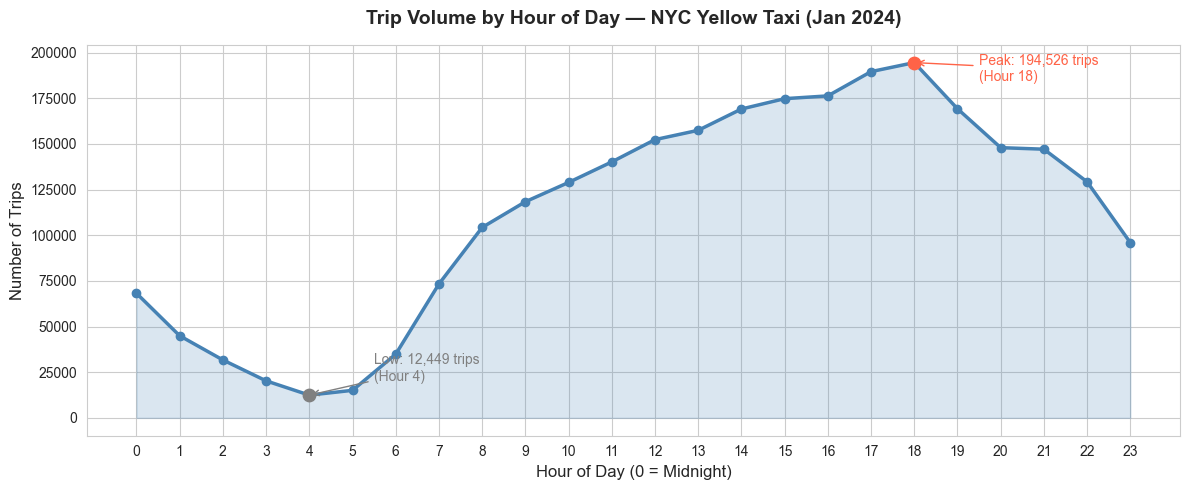

 hour_of_day  trip_count
           0       68223
           1       44955
           2       31710
           3       20274
           4       12449
           5       15091
           6       34869
           7       73320
           8      104278
           9      118345
          10      128909
          11      140148
          12      152351
          13      157452
          14      169114
          15      174778
          16      176296
          17      189583
          18      194526
          19      169248
          20      147956
          21      147111
          22      129247
          23       95964


In [12]:
# Cell 11: Chart 5 — Trip Volume by Hour
hourly_volume = df.groupby('hour_of_day').size().reset_index(name='trip_count')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hourly_volume['hour_of_day'], hourly_volume['trip_count'],
        color='steelblue', linewidth=2.5, marker='o', markersize=6)

ax.fill_between(hourly_volume['hour_of_day'], hourly_volume['trip_count'],
                alpha=0.2, color='steelblue')

# Highlight peak volume hour
peak_hour = hourly_volume.loc[hourly_volume['trip_count'].idxmax(), 'hour_of_day']
peak_vol = hourly_volume['trip_count'].max()
ax.annotate(f'Peak: {peak_vol:,} trips\n(Hour {peak_hour})',
            xy=(peak_hour, peak_vol),
            xytext=(peak_hour + 1.5, peak_vol - 10000),
            fontsize=10, color='tomato',
            arrowprops=dict(arrowstyle='->', color='tomato'))
ax.scatter(peak_hour, peak_vol, color='tomato', s=80, zorder=5)

# Highlight lowest volume hour
low_hour = hourly_volume.loc[hourly_volume['trip_count'].idxmin(), 'hour_of_day']
low_vol = hourly_volume['trip_count'].min()
ax.scatter(low_hour, low_vol, color='gray', s=80, zorder=5)
ax.annotate(f'Low: {low_vol:,} trips\n(Hour {low_hour})',
            xy=(low_hour, low_vol),
            xytext=(low_hour + 1.5, low_vol + 8000),
            fontsize=10, color='gray',
            arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_title('Trip Volume by Hour of Day — NYC Yellow Taxi (Jan 2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day (0 = Midnight)', fontsize=12)
ax.set_ylabel('Number of Trips', fontsize=12)
ax.set_xticks(range(24))

plt.tight_layout()
plt.show()

print(hourly_volume.to_string(index=False))

## Phase 5: Regression Model

Building a Linear Regression model to predict fare_amount using
engineered features. Evaluating with MAE, RMSE, and R².

**Features used:** trip_distance, trip_duration_mins, hour_of_day,
day_of_week, is_weekend, passenger_count

**Target variable:** fare_amount

**Note:** total_amount and tip_amount excluded to prevent data leakage.

In [13]:
# Cell 12: Prepare features and target

# Features — no total_amount, no tip_amount (data leakage)
features = ['trip_distance', 'trip_duration_mins', 'hour_of_day', 
            'day_of_week', 'is_weekend', 'passenger_count']

target = 'fare_amount'

# Drop any remaining nulls in our feature set
model_df = df[features + [target]].dropna()
print(f"Model dataset: {len(model_df):,} rows")

X = model_df[features]
y = model_df[target]

# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")

Model dataset: 2,696,197 rows
Training rows: 2,156,957
Testing rows:  539,240


In [14]:
# Cell 13: Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions on test set
y_pred = lr_model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Linear Regression Results ===")
print(f"MAE:  ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R²:   {r2:.4f}")

print("\n=== Model Coefficients ===")
for feature, coef in zip(features, lr_model.coef_):
    print(f"  {feature:<25} {coef:.4f}")
print(f"  {'Intercept':<25} {lr_model.intercept_:.4f}")

=== Linear Regression Results ===
MAE:  $2.41
RMSE: $4.07
R²:   0.9231

=== Model Coefficients ===
  trip_distance             3.4990
  trip_duration_mins        0.0129
  hour_of_day               -0.0013
  day_of_week               0.0518
  is_weekend                -0.7030
  passenger_count           0.1023
  Intercept                 6.4042


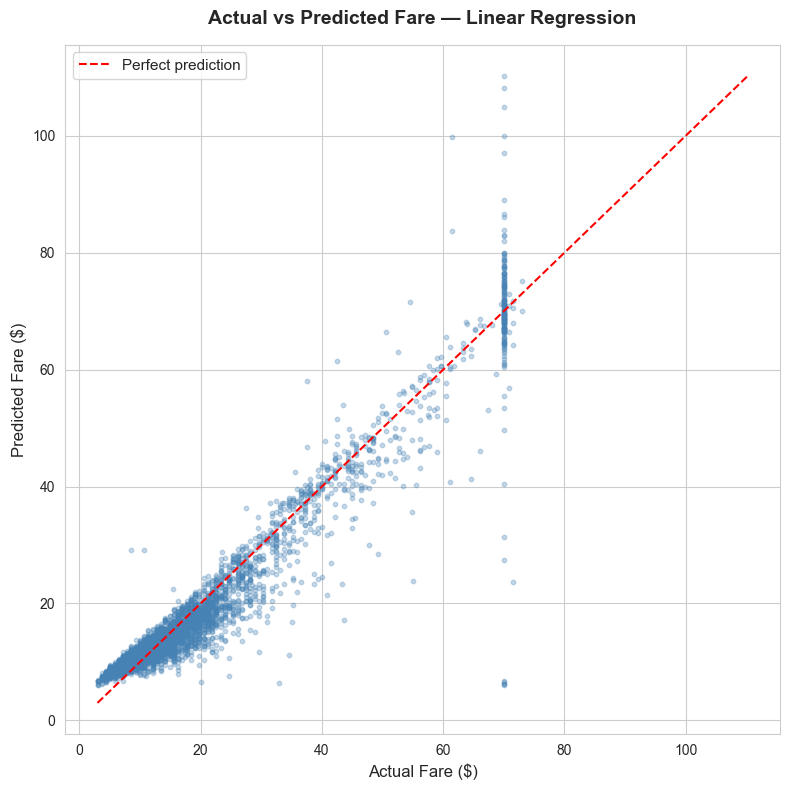

In [15]:
# Cell 14: Actual vs Predicted scatter plot
fig, ax = plt.subplots(figsize=(8, 8))

# Sample 5000 points so the plot renders cleanly
sample_idx = np.random.choice(len(y_test), 5000, replace=False)
y_test_sample = np.array(y_test)[sample_idx]
y_pred_sample = y_pred[sample_idx]

ax.scatter(y_test_sample, y_pred_sample,
           alpha=0.3, color='steelblue', s=10)

# Perfect prediction line
min_val = min(y_test_sample.min(), y_pred_sample.min())
max_val = max(y_test_sample.max(), y_pred_sample.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='red', linewidth=1.5, linestyle='--', label='Perfect prediction')

ax.set_title('Actual vs Predicted Fare — Linear Regression',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Actual Fare ($)', fontsize=12)
ax.set_ylabel('Predicted Fare ($)', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Phase 5 Model Summary

| Metric | Value | Interpretation |
|---|---|---|
| MAE | $2.41 | Average prediction error per trip |
| RMSE | $4.07 | Penalized error — driven by JFK flat-rate outliers |
| R² | 0.9231 | Model explains 92.3% of fare variation |

**Top predictors by coefficient:**
- trip_distance: +$3.50 per mile (dominant driver)
- is_weekend: -$0.70 (weekends are cheaper)
- passenger_count: +$0.10 (minimal impact)

**Known limitation:** JFK flat-rate trips ($70 fixed) cannot be
predicted accurately by a metered fare model — a separate
classification layer would be needed in production.

## Phase 5 Model Summary

| Metric | Value | Interpretation |
|---|---|---|
| MAE | $2.41 | Average prediction error per trip |
| RMSE | $4.07 | Penalized error — driven by JFK flat-rate outliers |
| R² | 0.9231 | Model explains 92.3% of fare variation |

**Top predictors by coefficient:**
- trip_distance: +$3.50 per mile (dominant driver)
- is_weekend: -$0.70 (weekends are cheaper)
- passenger_count: +$0.10 (minimal impact)

**Known limitation:** JFK flat-rate trips ($70 fixed) cannot be
predicted accurately by a metered fare model — a separate
classification layer would be needed in production.

## Phase 6: Business Summary — RideMetrics Inc.

---

### Executive Summary

RideMetrics Inc. commissioned an analysis of NYC Yellow Taxi trip data
for January 2024 (2,964,624 trips) to understand what drives fare amounts
and build a predictive model for operational planning.

After cleaning 9% of records for data quality issues, we engineered
meaningful features and trained a Linear Regression model that explains
**92.3% of fare variation** with an average prediction error of **$2.41 per trip**.

---

### Key Question 1: What factors most influence fare?

| Factor | Impact | Finding |
|---|---|---|
| Trip Distance | +$3.50 per mile | Strongest driver by far |
| Base Fare | +$6.40 fixed | Meter start charge |
| Weekend | -$0.70 | Weekends are slightly cheaper |
| Passenger Count | +$0.10 per person | Minimal impact |
| Hour of Day | Minimal linear effect | Non-linear pattern better captured in EDA |

**Recommendation:** Distance is king. RideMetrics Inc. should prioritize
dispatching strategies that maximize miles per trip, particularly
airport and outer-borough runs.

---

### Key Question 2: What time and day commands the highest fares?

- **Highest average fare:** 5 AM ($25.08) — pre-dawn airport runs
- **Highest trip volume:** 6 PM (194,526 trips) — evening rush hour
- **Most expensive day:** Monday ($18.57)
- **Cheapest day:** Saturday ($16.57)

**Recommendation:** Early morning shifts (4 AM–7 AM) generate the
highest fare per trip. RideMetrics Inc. should incentivize drivers
to work pre-dawn hours, particularly Monday through Thursday,
to maximize per-trip revenue.

---

### Key Question 3: What does the model error mean in dollar terms?

- The model's average error is **$2.41 per trip**
- On a median fare of $12.80, that is an **18.8% margin of error**
- For a driver completing 30 trips per day, cumulative prediction
  error could reach **$72/day** — acceptable for planning but
  not precise enough for real-time dynamic pricing

**Recommendation:** The current model is suitable for **demand
forecasting and shift planning**. For real-time fare estimation,
a more advanced model (Random Forest or Gradient Boosting)
and additional features (weather, events, traffic) would reduce
error further.

---

### Key Question 4: What would we recommend to RideMetrics Inc.?

1. **Target airport corridors** — JFK flat-rate trips ($70 fixed)
   are the highest single-fare opportunity. A dedicated airport
   dispatch queue would capture this reliably.

2. **Optimize early morning supply** — 4 AM–6 AM has the highest
   fare per trip but lowest driver supply. Closing this gap is
   the single biggest revenue opportunity.

3. **Build a two-model system** — a classifier to identify
   flat-rate airport trips first, then a regression model for
   all metered fares. This would reduce RMSE significantly.

4. **Enrich with external data** — adding weather conditions,
   NYC event calendars, and subway disruption alerts would
   likely push R² above 0.95.

5. **Monitor January patterns** — January is a low-demand winter
   month. Re-running this analysis on summer months (June–August)
   would reveal seasonal patterns for annual planning.

---

### Model Limitations

| Limitation | Impact |
|---|---|
| JFK flat-rate trips | Model cannot predict $70 fixed fares accurately |
| January data only | Seasonal patterns not captured |
| No weather data | Rain/snow significantly affects demand |
| Linear model | Cannot capture non-linear fare relationships |

---

*Analysis completed by Shadman Shahreaz | Data Source: NYC TLC Yellow Taxi Trip Data, January 2024*